<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="logo_udea.png" alt="Logo UdeA" style="height: 80px;">
  <div>
    <h1 style="margin: 0; font-size: 2em;">Proyecto 2 - Análisis espectral de señales ECG</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>



# Importación de librerías y funciones

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy import fft
from scipy.fftpack import dct
import matplotlib.pyplot as plt;
import scipy.io as sio;
import seaborn as sns
from scipy.signal import detrend
from scipy.signal import butter, filtfilt
from scipy.stats import ttest_ind, shapiro, levene, mannwhitneyu
from scipy import stats
import os
import librosa
import zipfile
from scipy.signal import welch

# Cargue del dataset

### a) Cargue del archivo "Diagnostics.xlsx'

In [3]:
data = pd.read_excel('C:\Programación\Bioseñales\proyecto2_ekg\Diagnostics.xlsx')
data

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10641,MUSE_20181222_204306_99000,SVT,NONE,80,FEMALE,196,73,168,284,513,258,244,32,177,261,319
10642,MUSE_20181222_204309_22000,SVT,NONE,81,FEMALE,162,81,162,294,482,110,-75,27,173,254,320
10643,MUSE_20181222_204310_31000,SVT,NONE,39,MALE,152,92,152,340,540,250,38,25,208,284,378
10644,MUSE_20181222_204312_58000,SVT,NONE,76,MALE,175,178,128,310,529,98,-83,29,205,269,360


### Extracción de los registros con ritmos tipo AFIB, SB y SR.

In [33]:
dataSB_FileName = data.loc[lambda x: x["Rhythm"] == "SB", "FileName"].tolist()
dataAFIB_FileName = data.loc[lambda x: x["Rhythm"] == "AFIB", "FileName"].tolist()
dataSR_FileName = data.loc[lambda x: x["Rhythm"] == "SR", "FileName"].tolist()

print(f"Cantidad de archivos para SB (bradicardia sinusal): {len(dataSB_FileName)}")
print(f"Cantidad de archivos para AFIB (fibrilación auricular): {len(dataAFIB_FileName)}")
print(f"Cantidad de archivos para SR (ritmo sinusal): {len(dataSR_FileName)}")

Cantidad de archivos para SB (bradicardia sinusal): 3889
Cantidad de archivos para AFIB (fibrilación auricular): 1780
Cantidad de archivos para SR (ritmo sinusal): 1826


In [34]:

dataAFIB_FileName_csv = [f"{archivo}.csv" for archivo in dataAFIB_FileName]
dataSB_FileName_csv = [f"{archivo}.csv" for archivo in dataSB_FileName]
dataSR_FileName_csv = [f"{archivo}.csv" for archivo in dataSR_FileName]

In [29]:
directorio_actual = os.getcwd()
folder = os.listdir(directorio_actual+"/ECGDataDenoised/ECGDataDenoised")

Se recorre la carpeta con todas las señales para extraer las que corresponden a los ritmos de interés.

In [35]:
SB_registers = []
AFIB_registers = []
SR_registers = []

for archivo in folder:
    if archivo in dataSB_FileName_csv:
        SB_registers.append(archivo)
    if archivo in dataAFIB_FileName_csv:
        AFIB_registers.append(archivo)
    if archivo in dataSR_FileName_csv:
        SR_registers.append(archivo)
    




In [36]:
len(SB_registers), len(AFIB_registers), len(SR_registers)

(3889, 1780, 1826)

Creación de un DataFrame para almancenar las señales de interés y su etiqueta., 

In [ ]:
dataset = []
for registro in SB_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'SB'})

for registro in AFIB_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'AFIB'})

for registro in SR_registers:
    dataset.append({'Registro': registro, 'Ritmo': 'SR'})

dataframe_ritmos = pd.DataFrame(dataset)

print(dataframe_ritmos)

                            Registro Ritmo
0     MUSE_20180111_155758_17000.csv    SB
1     MUSE_20180111_155839_67000.csv    SB
2     MUSE_20180111_155859_36000.csv    SB
3     MUSE_20180111_155907_78000.csv    SB
4     MUSE_20180111_160033_11000.csv    SB
...                              ...   ...
7490  MUSE_20180210_133122_64000.csv    SR
7491  MUSE_20180210_133123_70000.csv    SR
7492  MUSE_20180210_133136_06000.csv    SR
7493  MUSE_20180210_133138_18000.csv    SR
7494  MUSE_20180210_133139_22000.csv    SR

[7495 rows x 2 columns]


#### Señales de la derivación II

In [46]:
def derivacion_dos(carpeta, archivo, columnas):
    ruta = os.path.join(carpeta, archivo) 
    try:
        df = pd.read_csv(ruta, delimiter=',', names=columnas)
        signal = df["II"]
    except FileNotFoundError:
        print(f'El archivo {archivo} no se encontró en {carpeta}.')
    return signal

In [47]:
df_SB_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'SB']
df_AFIB_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'AFIB']
df_SR_files = dataframe_ritmos[dataframe_ritmos['Ritmo'] == 'SR']


columnas = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
ruta = directorio_actual + "/ECGDataDenoised/ECGDataDenoised"

lista_SB_II = []
lista_AFIB_II = []
lista_SR_II = []

for archivo in df_SB_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "SB"}
    lista_SB_II.append(data)

for archivo in df_AFIB_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "AFIB"}
    lista_AFIB_II.append(data)

for archivo in df_SR_files['Registro']:
    signal = derivacion_dos(ruta, archivo, columnas)
    data = {"Registros": archivo, "II": signal, "Ritmo": "SR"}
    lista_SR_II.append(data)



df_signals = pd.DataFrame(lista_SB_II + lista_AFIB_II + lista_SR_II)
df_signals.index = df_signals.index + 1


In [48]:
df_signals

,Registros,II,Ritmo
1,MUSE_20180111_155758_17000.csv,0 362.880 1 310.670 2 263.87...,SB
2,MUSE_20180111_155839_67000.csv,0 20.0040 1 22.1440 2 22.996...,SB
3,MUSE_20180111_155859_36000.csv,0 -3.03400 1 -2.30080 2 -1.0...,SB
4,MUSE_20180111_155907_78000.csv,0 -26.45100 1 -8.01570 2 ...,SB
5,MUSE_20180111_160033_11000.csv,0 11.3730 1 4.3521 2 -1.206...,SB
...,...,...,...
7491,MUSE_20180210_133122_64000.csv,0 -26.554 1 -28.265 2 -30.05...,SR
7492,MUSE_20180210_133123_70000.csv,0 16.2330 1 4.2384 2 -6....,SR
7493,MUSE_20180210_133136_06000.csv,0 31.0470 1 25.4140 2 22....,SR
7494,MUSE_20180210_133138_18000.csv,0 -6.0006 1 -3.2482 2 -1.456...,SR


In [ ]:
def guardar_archivos(df, carpeta): #Función para guardar los registros de la II derivación
    for _, row in df.iterrows():
        nombre_archivo = row['Registros'] 
        señal = row['II']  
        ruta_guardar = os.path.join(carpeta, nombre_archivo)
        
        
        with open(ruta_guardar, 'w') as f:
            for dato in señal:
                f.write(f"{dato}\n")

In [ ]:
sb_folder = "SB" 
afib_folder = "AFIB"
sr_folder = "SR"

df_SB = df_signals[df_signals['Ritmo'] == 'SB'] 
df_AFIB = df_signals[df_signals['Ritmo'] == 'AFIB']
df_SR = df_signals[df_signals['Ritmo'] == 'SR']

if not os.path.exists(sb_folder):
    os.makedirs(sb_folder)
    print(f"Carpeta '{sb_folder}' creada.")
    guardar_archivos(df_SB, sb_folder)
    print('Archivos de SB guardados correctamente')
else:
    print(f"Carpeta '{sb_folder}' ya existe.")

if not os.path.exists(afib_folder):
    os.makedirs(afib_folder)
    print(f"Carpeta '{afib_folder}' creada.")
    guardar_archivos(df_AFIB, afib_folder)
    print('Archivos de AFIB guardados correctamente')
else:
    print(f"Carpeta '{afib_folder}' ya existe.")

if not os.path.exists(sr_folder):
    os.makedirs(sr_folder)
    print(f"Carpeta '{sr_folder}' creada.")
    guardar_archivos(df_SR, sr_folder)
    print('Archivos de SR guardados correctamente')
else:
    print(f"Carpeta '{sr_folder}' ya existe.")

Carpeta 'SB' creada.
Archivos de SB guardados correctamente
Carpeta 'AFIB' creada.
Archivos de AFIB guardados correctamente
Carpeta 'SR' creada.
Archivos de SR guardados correctamente


# Extracción de características 

## Extracción de características usando la Transformada Discreta de Fourier

### Transformada rápida de Fourier (FFT) a las señales 

La DFT (Transformada discreta de Fourier) se usa para analizar la distribución espectral de una señal ECG, puesto que muchas anormalidades cardíacas introducen componentes de frecuencia que no están presentes en señales normales. Sin embargo el costo computacional de la DFT es muy alto, por lo que se recurre a un método más rápido, llamado FFT (Transformada rápida de Fourier)

In [ ]:
#Función para cargar señales desde csv

def cargar_senal_csv(ruta_archivo):
    """Carga una señal desde un archivo CSV"""
    df = pd.read_csv(ruta_archivo, header=None)
    return df.iloc[:, 0].dropna().astype(float).values

def transformada_fft(senal, fs=500):
    n = len(senal)
    fft_vals = np.fft.fft(senal)
    freqs = np.fft.fftfreq(n, d=1/fs)
    magnitudes = np.abs(fft_vals)
    return freqs[:n // 2], magnitudes[:n // 2]

def procesar_carpeta(nombre_carpeta, etiqueta):
    resultados = []
    for archivo in os.listdir(nombre_carpeta):
        ruta = os.path.join(nombre_carpeta, archivo)
        try:
            senal = cargar_senal_csv(ruta)
            if len(senal) != 5000:
                print(f"Omitiendo {archivo}: tamaño inesperado {len(senal)}")
                continue
            freqs, mags = transformada_fft(senal)
            for f, m in zip(freqs, mags):
                resultados.append({
                    'archivo': archivo,
                    'grupo': etiqueta,
                    'frecuencia': f,
                    'magnitud': m
                })
        except Exception as e:
            print(f"Error con {archivo}: {e}")
    return resultados

In [54]:
resultados = []
resultados += procesar_carpeta('SB', 'SB')
resultados += procesar_carpeta('AFIB', 'AFIB')
resultados += procesar_carpeta('SR', 'SR')

df_fft = pd.DataFrame(resultados)


Omitiendo MUSE_20180113_124215_52000.csv: tamaño inesperado 1926


In [56]:
df_fft
df_fft.to_csv("espectros_fft_todos.csv", index=False)


### Extracción de características con FFT

In [111]:

def calcular_caracteristicas(grupo_df):
    mags = grupo_df['magnitud'].values
    freqs = grupo_df['frecuencia'].values

    energy = np.sum(mags ** 2)
    peak_freq = freqs[np.argmax(mags)]
    mean_mag = np.mean(mags)
    var_mag = np.var(mags)


    # Primeros 10 coeficientes espectrales 
    coeffs = mags[:10]
    coeffs = np.pad(coeffs, (0, 10 - len(coeffs)), constant_values=0)

    return pd.Series({
        'fft_energy': energy,
        'fft_peak_freq': peak_freq,
        'fft_mean_mag': mean_mag,
        'fft_var_mag': var_mag,
        
        **{f'fft_coeff_{i}': c for i, c in enumerate(coeffs)}
    })

# Agrupar por archivo
fft_caracteristicas = df_fft.groupby(['archivo', 'grupo']).apply(calcular_caracteristicas).reset_index()


C:\Users\tahol\AppData\Local\Temp\ipykernel_17840\909425704.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fft_caracteristicas = df_fft.groupby(['archivo', 'grupo']).apply(calcular_caracteristicas).reset_index()


In [112]:
fft_caracteristicas

,archivo,grupo,fft_energy,fft_peak_freq,fft_mean_mag,fft_var_mag,fft_coeff_0,fft_coeff_1,fft_coeff_2,fft_coeff_3,fft_coeff_4,fft_coeff_5,fft_coeff_6,fft_coeff_7,fft_coeff_8,fft_coeff_9
0,MUSE_20180111_155154_74000.csv,AFIB,1.464336e+11,0.0,2252.596369,5.349925e+07,110777.159595,4209.264998,4456.571325,2536.879020,1262.049605,9758.881570,11049.727192,7901.853424,8072.754539,8164.550823
1,MUSE_20180111_155203_15000.csv,AFIB,1.291414e+11,0.0,2150.559389,4.703165e+07,119868.706387,19656.817082,5717.197029,17078.524395,13515.774819,6147.071252,13290.879538,30302.538162,37971.230190,22239.514935
2,MUSE_20180111_155758_17000.csv,SB,2.828820e+11,0.0,3235.846147,1.026821e+08,180544.464437,3013.153119,1872.548288,5833.067656,2196.420104,3873.040213,11773.171332,5681.453330,22738.577025,135288.420798
3,MUSE_20180111_155839_67000.csv,SB,4.274610e+10,2.9,1256.319064,1.552010e+07,50980.215712,1549.978669,2519.373942,3111.853946,3016.059314,3465.441674,3189.097304,1690.767419,3206.022129,12212.212452
4,MUSE_20180111_155859_36000.csv,SB,1.199978e+11,0.0,1857.319797,4.454947e+07,130490.530090,3010.205689,3269.288274,10211.393760,4764.023543,5885.124218,8173.569041,14303.504005,23896.971434,108426.733292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7489,MUSE_20180712_161449_58000.csv,AFIB,4.009579e+11,12.4,4259.518789,1.422397e+08,49512.607035,22896.342179,26292.713393,25216.940663,29331.654859,30686.722790,35888.931058,48417.510476,56249.652570,53158.471955
7490,MUSE_20180712_161451_72000.csv,AFIB,7.518653e+10,0.0,1495.972624,2.783668e+07,98426.832232,9094.660702,17870.748440,11544.345114,7111.024007,13779.610491,4313.082103,2012.176226,13681.316322,6012.144116
7491,MUSE_20180712_161452_78000.csv,AFIB,2.626611e+11,0.0,2879.405978,9.677346e+07,216906.128766,35536.174900,14147.876185,7538.895027,17746.973870,28181.816244,17806.876458,56337.061357,20177.814585,79245.697240
7492,MUSE_20180712_161503_00000.csv,AFIB,8.314556e+10,0.0,1595.150891,3.071372e+07,133710.706354,6594.186121,13817.548619,11167.153038,9642.569933,1803.699982,1990.375464,11038.972076,9252.334600,11830.924652


## Extracción de características usando la transformada discreta de coseno (DCT)

La DCT transforma una señal del dominio del tiempo al dominio de la frecuencia, como la FFT, pero usando solo cosenos reales.

el Algoritmo 10 del artículo, propone extraer características con DCT no directamente sobre la señal, sino sobre su autocorrelación, después de filtrar y detectar los picos R.

In [ ]:
def butter_bandpass_filter(signal, lowcut=1, highcut=40, fs=500, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)


In [74]:
from scipy.signal import find_peaks

def detectar_r_peaks(signal, fs=500):
    peaks, _ = find_peaks(signal, distance=fs*0.6, height=np.mean(signal))  # ritmo mínimo ~60 lpm
    return peaks


In [75]:
def autocorrelacion(signal, num_coef=21):
    r = np.correlate(signal, signal, mode='full')
    r = r[len(r)//2:]  # parte positiva
    return r[:num_coef]


In [ ]:

def extraer_dct_de_autocorrelacion(signal, fs=500):
    filtrada = butter_bandpass_filter(signal, fs=fs)
    r_peaks = detectar_r_peaks(filtrada, fs)
    
    if len(r_peaks) < 2:
        return np.zeros(10)  

    segmento = filtrada[r_peaks[0]:r_peaks[1]]
    
    autoc = autocorrelacion(segmento, num_coef=21)
    dct_vals = dct(autoc, type=2, norm='ortho')
    return dct_vals[:10]


In [82]:
def procesar_dct_autocorrelacion(carpeta, etiqueta):
    resultados = []
    for archivo in os.listdir(carpeta):
        if not archivo.endswith('.csv'):
            continue
        ruta = os.path.join(carpeta, archivo)
        try:
            senal = cargar_senal_csv(ruta)  
            coef = extraer_dct_de_autocorrelacion(senal)
            resultados.append({
                'archivo': archivo,
                'grupo': etiqueta,
                **{f'coef{i}': c for i, c in enumerate(coef)}
            })
        except Exception as e:
            print(f"Error en {archivo}: {e}")
    return resultados


In [83]:
resultados_DCT = []
resultados_DCT += procesar_dct_autocorrelacion('SB', 'SB')
resultados_DCT += procesar_dct_autocorrelacion('AFIB', 'AFIB')
resultados_DCT += procesar_dct_autocorrelacion('SR', 'SR')

df_dct = pd.DataFrame(resultados_DCT)


In [84]:
df_dct

,archivo,grupo,coef0,coef1,coef2,coef3,coef4,coef5,coef6,coef7,coef8,coef9
0,MUSE_20180111_155758_17000.csv,SB,5.184597e+06,4.697429e+06,2.184852e+06,1.277922e+06,6.078629e+05,304296.038492,190954.092417,134391.718236,96637.727607,75122.179484
1,MUSE_20180111_155839_67000.csv,SB,2.609710e+06,2.309152e+06,9.269966e+05,1.701024e+05,1.377010e+05,46297.220233,41782.973729,20692.347719,21371.895229,11671.035136
2,MUSE_20180111_155859_36000.csv,SB,1.100107e+07,2.483031e+06,7.896072e+05,7.507422e+05,1.416694e+05,129838.558965,25507.567116,56689.040309,10880.195644,31576.000931
3,MUSE_20180111_155907_78000.csv,SB,9.517254e+06,6.111878e+06,2.566950e+06,7.616731e+05,3.416707e+05,141351.070945,101703.212100,62702.419969,51194.013814,35077.244461
4,MUSE_20180111_160033_11000.csv,SB,3.656806e+06,6.387275e+06,5.100659e+06,1.884807e+06,6.807642e+05,372900.083099,230624.032715,162909.282539,118238.698717,90518.538838
...,...,...,...,...,...,...,...,...,...,...,...,...
7490,MUSE_20180210_133122_64000.csv,SR,4.912892e+06,2.068342e+06,2.308819e+05,2.570380e+05,3.581281e+04,53742.790557,5644.548329,25643.243744,2275.737390,14667.548843
7491,MUSE_20180210_133123_70000.csv,SR,1.416032e+07,1.584841e+07,8.744325e+06,4.452456e+06,1.527599e+06,861973.609354,486975.107012,384292.218073,247594.525747,215002.394967
7492,MUSE_20180210_133136_06000.csv,SR,2.712066e+06,3.869171e+06,2.900898e+06,1.164946e+06,3.896024e+05,196185.923766,125108.194197,87286.322903,64345.414358,48745.731429
7493,MUSE_20180210_133138_18000.csv,SR,3.360400e+06,8.338372e+06,4.706016e+06,1.029689e+06,5.100408e+05,173566.354119,181115.568951,74810.017804,93048.053706,41214.150776


In [ ]:

def extraer_stats_dct(fila):
    # Buscar las columnas coef0, coef1, ..., coef9
    coef_cols = [col for col in fila.index if col.startswith('coef')]
    coef = fila[coef_cols].values.astype(np.float64)

    # Verificación rápida: evitar división por cero o vectores vacíos
    if len(coef) == 0 or np.all(coef == 0):
        return pd.Series({
            'mean_dct': np.nan,
            'var_dct': np.nan,
            'max_dct': np.nan,
            'min_dct': np.nan,
            'energy_dct': np.nan,
            'entropy_dct': np.nan
        })

    energy = np.sum(coef ** 2)
    p = coef**2 / np.sum(coef**2)
    entropy = -np.sum(p * np.log2(p + 1e-12))  # evitar log(0)

    return pd.Series({
        'mean_dct': np.mean(coef),
        'var_dct': np.var(coef),
        'max_dct': np.max(coef),
        'min_dct': np.min(coef),
        'energy_dct': energy,
        'entropy_dct': entropy
    })


In [101]:
df_dct_stats = df_dct.copy()
stats = df_dct.apply(extraer_stats_dct, axis=1)
df_dct_stats = pd.concat([df_dct_stats, stats], axis=1)


In [102]:
df_dct_stats

,archivo,grupo,coef0,coef1,coef2,coef3,coef4,coef5,coef6,coef7,coef8,coef9,mean_dct,var_dct,max_dct,min_dct,energy_dct,entropy_dct
0,MUSE_20180111_155758_17000.csv,SB,5.184597e+06,4.697429e+06,2.184852e+06,1.277922e+06,6.078629e+05,304296.038492,190954.092417,134391.718236,96637.727607,75122.179484,1.475407e+06,3.411590e+12,5.184597e+06,75122.179484,5.588415e+13,1.566619
1,MUSE_20180111_155839_67000.csv,SB,2.609710e+06,2.309152e+06,9.269966e+05,1.701024e+05,1.377010e+05,46297.220233,41782.973729,20692.347719,21371.895229,11671.035136,6.295477e+05,9.091593e+11,2.609710e+06,11671.035136,1.305490e+13,1.313928
2,MUSE_20180111_155859_36000.csv,SB,1.100107e+07,2.483031e+06,7.896072e+05,7.507422e+05,1.416694e+05,129838.558965,25507.567116,56689.040309,10880.195644,31576.000931,1.542061e+06,1.046385e+13,1.100107e+07,10880.195644,1.284180e+14,0.366926
3,MUSE_20180111_155907_78000.csv,SB,9.517254e+06,6.111878e+06,2.566950e+06,7.616731e+05,3.416707e+05,141351.070945,101703.212100,62702.419969,51194.013814,35077.244461,1.969145e+06,9.648206e+12,9.517254e+06,35077.244461,1.352574e+14,1.158779
4,MUSE_20180111_160033_11000.csv,SB,3.656806e+06,6.387275e+06,5.100659e+06,1.884807e+06,6.807642e+05,372900.083099,230624.032715,162909.282539,118238.698717,90518.538838,1.868550e+06,4.952833e+12,6.387275e+06,90518.538838,8.444313e+13,1.713870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7490,MUSE_20180210_133122_64000.csv,SR,4.912892e+06,2.068342e+06,2.308819e+05,2.570380e+05,3.581281e+04,53742.790557,5644.548329,25643.243744,2275.737390,14667.548843,7.606941e+05,2.275245e+12,4.912892e+06,2275.737390,2.853900e+13,0.654547
7491,MUSE_20180210_133123_70000.csv,SR,1.416032e+07,1.584841e+07,8.744325e+06,4.452456e+06,1.527599e+06,861973.609354,486975.107012,384292.218073,247594.525747,215002.394967,4.692896e+06,3.313108e+13,1.584841e+07,215002.394967,5.515435e+14,1.671933
7492,MUSE_20180210_133136_06000.csv,SR,2.712066e+06,3.869171e+06,2.900898e+06,1.164946e+06,3.896024e+05,196185.923766,125108.194197,87286.322903,64345.414358,48745.731429,1.155835e+06,1.895860e+12,3.869171e+06,48745.731429,3.231816e+13,1.756572
7493,MUSE_20180210_133138_18000.csv,SR,3.360400e+06,8.338372e+06,4.706016e+06,1.029689e+06,5.100408e+05,173566.354119,181115.568951,74810.017804,93048.053706,41214.150776,1.850827e+06,7.011099e+12,8.338372e+06,41214.150776,1.043666e+14,1.310108


### Extracción de características usando MFCC

El MFCC (Mel-Frequency Cepstral Coefficients) es una representación del contenido espectral de una señal transformada a un eje de percepción humana de frecuencias (escala Mel), muy usada en audio, pero útil también en señales como el ECG.

In [108]:
def cargar_senal_csv(ruta_archivo):
    df = pd.read_csv(ruta_archivo, header=None)
    return df.iloc[:, 0].dropna().astype(float).values

def calcular_mfcc_ecg(senal, fs=500, n_mfcc=13, frame_duration_ms=25):
    senal = senal.astype(np.float32)
    frame_length = int(fs * frame_duration_ms / 1000)
    hop_length = frame_length // 2
    mfccs = librosa.feature.mfcc(y=senal, sr=fs, n_mfcc=n_mfcc,
                                 n_fft=frame_length, hop_length=hop_length,
                                 fmin=1, fmax=40)
    return mfccs

def procesar_mfcc_por_carpeta(carpeta, etiqueta):
    datos = []
    for archivo in os.listdir(carpeta):
        if not archivo.endswith('.csv'):
            continue
        ruta = os.path.join(carpeta, archivo)
        try:
            senal = cargar_senal_csv(ruta)
            if len(senal) != 5000:
                print(f"Señal ignorada (longitud inesperada): {archivo}")
                continue
            mfccs = calcular_mfcc_ecg(senal)
            datos.append({
                'archivo': archivo,
                'grupo': etiqueta,
                'mfccs': mfccs  # Guardamos la matriz MFCC tal cual
            })
        except Exception as e:
            print(f"Error con {archivo}: {e}")
    return datos

In [110]:
df_mfcc

,archivo,grupo,mfccs
0,MUSE_20180111_155758_17000.csv,SB,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."
1,MUSE_20180111_155839_67000.csv,SB,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."
2,MUSE_20180111_155859_36000.csv,SB,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."
3,MUSE_20180111_155907_78000.csv,SB,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."
4,MUSE_20180111_160033_11000.csv,SB,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."
...,...,...,...
7489,MUSE_20180210_133122_64000.csv,SR,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."
7490,MUSE_20180210_133123_70000.csv,SR,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."
7491,MUSE_20180210_133136_06000.csv,SR,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."
7492,MUSE_20180210_133138_18000.csv,SR,"[[-1131.3708, -1131.3708, -1131.3708, -1131.37..."


# Comparación de características entre grupos

### Análisis descriptivo e inferencial de las características DFT

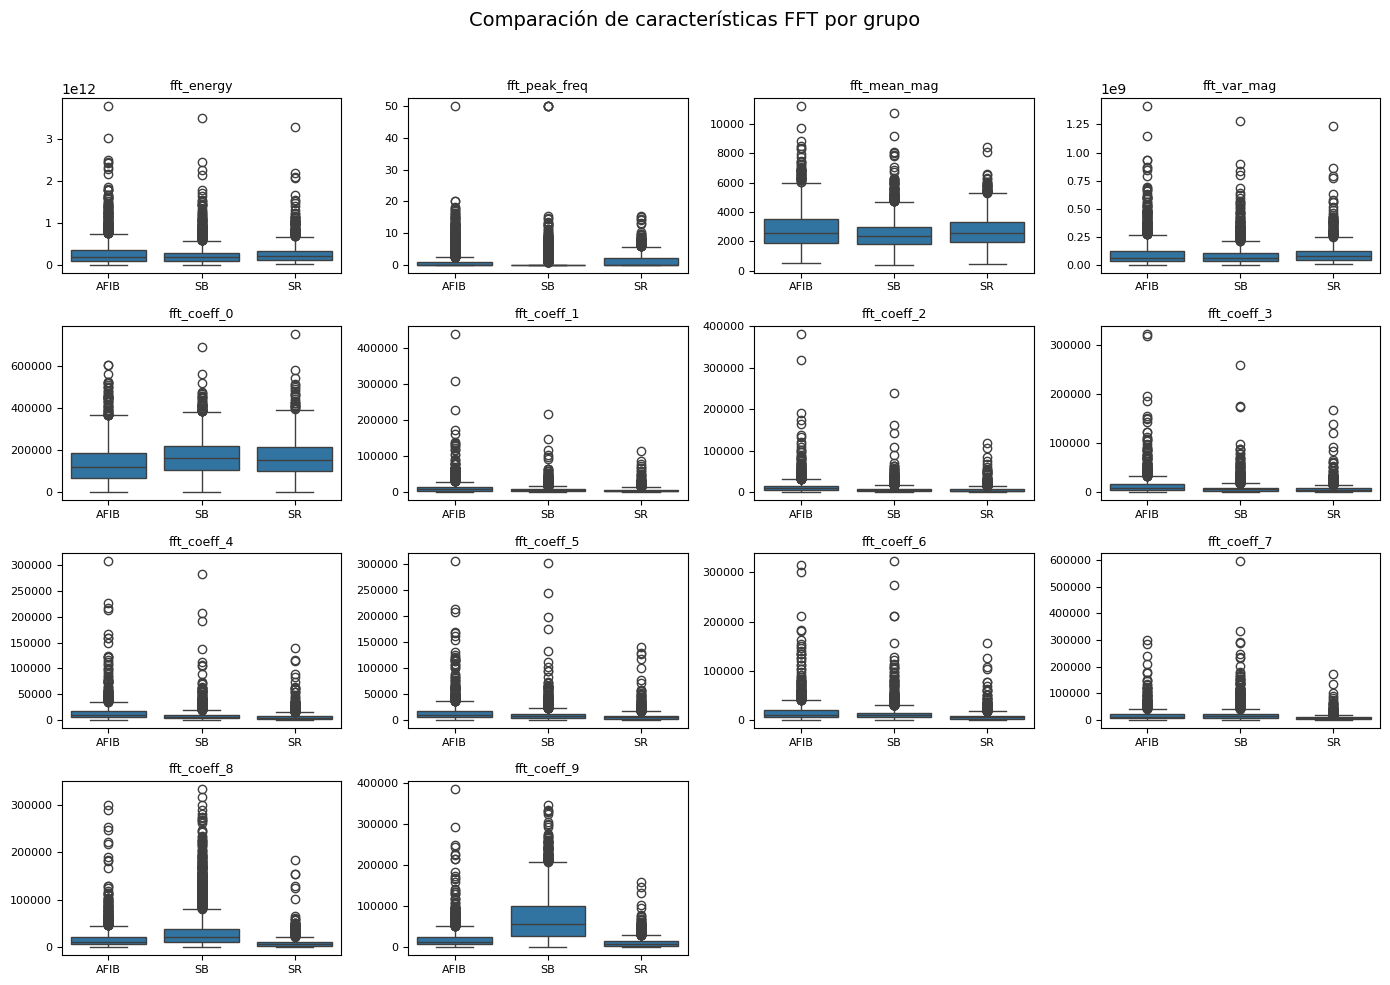

In [ ]:
cols_fft = [col for col in fft_caracteristicas.columns if col.startswith('fft_')]

n_cols = 4
n_rows = (len(cols_fft) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_fft):
    sns.boxplot(x='grupo', y=col, data=fft_caracteristicas, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar espacio
fig.suptitle('Comparación de características FFT por grupo', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



### Análisis descriptivo e inferencial de las características DCT

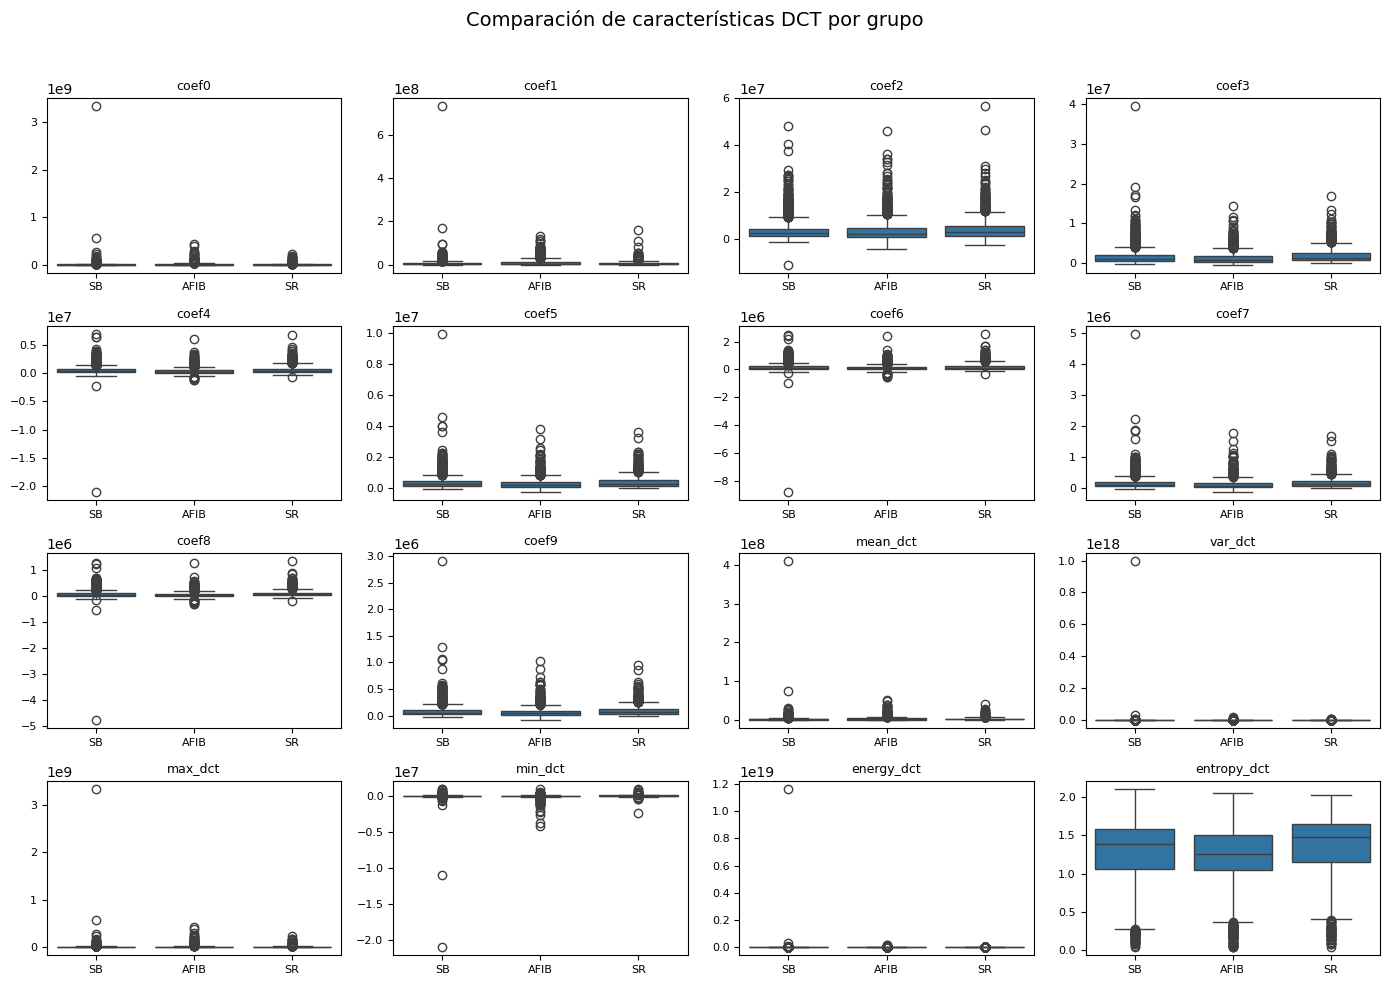

In [122]:

# Lista completa de columnas a graficar
cols_dct = ['coef0', 'coef1', 'coef2', 'coef3', 'coef4', 'coef5', 'coef6', 'coef7', 'coef8', 'coef9',
            'mean_dct', 'var_dct', 'max_dct', 'min_dct', 'energy_dct', 'entropy_dct']

# Número de columnas por fila en la figura
n_cols = 4
n_rows = (len(cols_dct) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_dct):
    sns.boxplot(x='grupo', y=col, data=df_dct_stats, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(labelsize=8)

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Comparación de características DCT por grupo', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Análisis descriptivo e inferencial de las características MFCC